In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

## Sample Project Estimation Dataset

In [5]:
np.random.seed(42)

n = 500

project_size = np.random.randint(5, 80, n)              # number of tasks/features
team_size = np.random.randint(1, 8, n)                  # people involved
complexity = np.random.choice(['Low', 'Medium', 'High'], n, p=[0.3, 0.5, 0.2])
client_type = np.random.choice(['SME', 'Enterprise'], n, p=[0.6, 0.4])
integrations = np.random.randint(0, 6, n)              # number of external systems
uses_ai = np.random.choice(['No', 'Yes'], n, p=[0.7, 0.3])
uses_automation = np.random.choice(['No', 'Yes'], n, p=[0.5, 0.5])

# Build target with some logic + noise
complexity_weight = {'Low': 0, 'Medium': 25, 'High': 60}
client_weight = {'SME': 0, 'Enterprise': 30}
ai_weight = {'No': 0, 'Yes': 20}
automation_weight = {'No': 0, 'Yes': 15}

estimated_hours = (
    project_size * 3.5
    + team_size * 8
    + np.array([complexity_weight[c] for c in complexity])
    + np.array([client_weight[c] for c in client_type])
    + integrations * 12
    + np.array([ai_weight[c] for c in uses_ai])
    + np.array([automation_weight[c] for c in uses_automation])
    + np.random.normal(0, 20, n)
)

df = pd.DataFrame({
    'project_size': project_size,
    'team_size': team_size,
    'complexity': complexity,
    'client_type': client_type,
    'integrations': integrations,
    'uses_ai': uses_ai,
    'uses_automation': uses_automation,
    'estimated_hours': estimated_hours
})

df.head()

,project_size,team_size,complexity,client_type,integrations,uses_ai,uses_automation,estimated_hours
0,56,1,High,SME,2,No,No,286.331241
1,19,2,High,SME,1,No,No,125.507096
2,76,3,High,Enterprise,4,No,Yes,424.562804
3,65,2,Low,Enterprise,0,Yes,Yes,288.420853
4,25,2,Medium,SME,2,Yes,No,176.645347


In [7]:
df.shape

(500, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   project_size     500 non-null    int64  
 1   team_size        500 non-null    int64  
 2   complexity       500 non-null    str    
 3   client_type      500 non-null    str    
 4   integrations     500 non-null    int64  
 5   uses_ai          500 non-null    str    
 6   uses_automation  500 non-null    str    
 7   estimated_hours  500 non-null    float64
dtypes: float64(1), int64(3), str(4)
memory usage: 31.4 KB


In [9]:
df.describe()

,project_size,team_size,integrations,estimated_hours
count,500.000000,500.000000,500.000000,500.000000
mean,41.142000,4.012000,2.560000,257.758947
std,21.667506,2.021888,1.708871,90.046386
min,5.000000,1.000000,0.000000,45.227931
25%,22.000000,2.000000,1.000000,192.858345
50%,40.000000,4.000000,3.000000,261.740000
75%,61.000000,6.000000,4.000000,325.283583
max,79.000000,7.000000,5.000000,477.028986


In [10]:
df['complexity'].value_counts()


complexity
Medium    238
Low       154
High      108
Name: count, dtype: int64

In [11]:
df['client_type'].value_counts()

client_type
SME           294
Enterprise    206
Name: count, dtype: int64

In [12]:
df.isnull().sum()

project_size       0
team_size          0
complexity         0
client_type        0
integrations       0
uses_ai            0
uses_automation    0
estimated_hours    0
dtype: int64

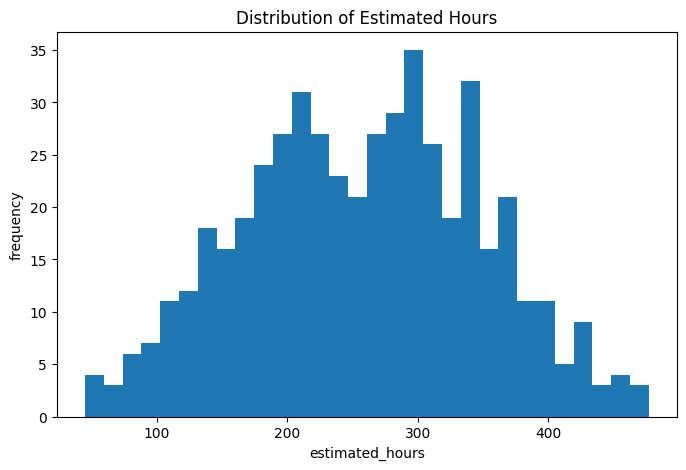

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df['estimated_hours'],bins=30)
plt.xlabel('estimated_hours')
plt.ylabel('frequency')
plt.title('Distribution of Estimated Hours')
plt.show()

In [14]:
X = df.drop(columns=['estimated_hours'])
y = df['estimated_hours']

In [15]:
numeric_features = ['project_size', 'team_size', 'integrations']
categorical_features = ['complexity','client_type', 'uses_ai', 'uses_automation']

## Preprocessing Data

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## Train/ Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression

In [ ]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

### Evaluate 


In [ ]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Result")
print("MAE: ", lr_mae)
print("RMSE: ", lr_rmse)
print("R2: ", lr_r2)

Linear Regression Result
MAE:  15.974062107717096
RMSE:  20.261024410290034
R2:  0.9518254699742659


## Decision Tree

In [21]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)

### Evaluate

In [23]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Result")
print("MAE: ", dt_mae)
print("RMSE: ", dt_rmse)
print("R2: ", dt_r2)

Decision Tree Result
MAE:  35.166913739040595
RMSE:  43.4841380085903
R2:  0.778100451896423


## Random Forest

In [24]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

### Evaluate

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Result")
print("MAE: ", rf_mae)
print("RMSE: ", rf_rmse)
print("R2: ", rf_r2)

Random Forest Result
MAE:  22.256999535940075
RMSE:  28.53520538203299
R2:  0.9044442792928433


## XGBoost

In [26]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=200, 
        max_depth=4, 
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

### Evaluate

In [27]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Result")
print("MAE: ", xgb_mae)
print("RMSE: ", xgb_rmse)
print("R2: ", xgb_r2)

XGBoost Result
MAE:  18.463839152403544
RMSE:  24.82157762055911
R2:  0.9276974775166182


## Results Comparison

In [28]:
results= pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, dt_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, xgb_rmse],
    'R2': [lr_r2, dt_r2, rf_r2, xgb_r2]
})

results.sort_values(by='RMSE')


,Model,MAE,RMSE,R2
0,Linear Regression,15.974062,20.261024,0.951825
3,XGBoost,18.463839,24.821578,0.927697
2,Random Forest,22.257000,28.535205,0.904444
1,Decision Tree,35.166914,43.484138,0.778100


## Plot actual vs predicted

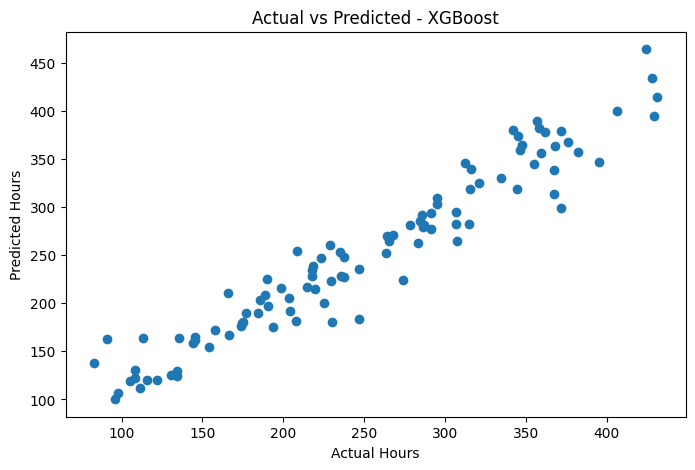

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Hours")
plt.ylabel("Predicted Hours")
plt.title("Actual vs Predicted - XGBoost")
plt.show()

## Feature importance for Random Forest

In [31]:
rf_model = rf_pipeline.named_steps['model']
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_cat_features)

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
0,project_size,0.804361
2,integrations,0.064229
1,team_size,0.050222
3,complexity_High,0.025662
4,complexity_Low,0.019933
6,client_type_Enterprise,0.009577
7,client_type_SME,0.009005
10,uses_automation_No,0.003741
11,uses_automation_Yes,0.003615
5,complexity_Medium,0.003517


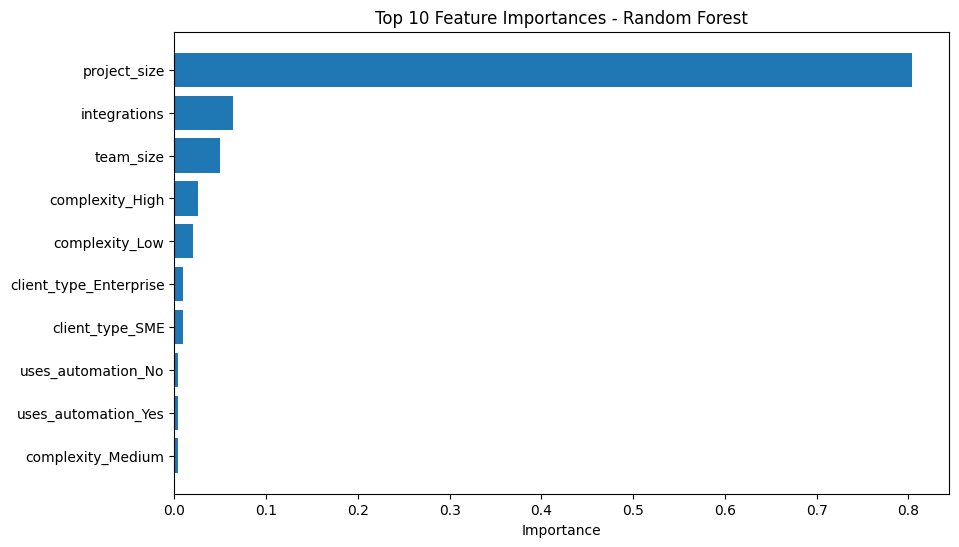

In [32]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

In [33]:
xgb_model = xgb_pipeline.named_steps['model']

xgb_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

xgb_importance_df.head(10)

,Feature,Importance
0,project_size,0.440089
3,complexity_High,0.105480
4,complexity_Low,0.092818
2,integrations,0.075531
7,client_type_SME,0.073155
6,client_type_Enterprise,0.061479
1,team_size,0.052940
9,uses_ai_Yes,0.029590
10,uses_automation_No,0.027200
8,uses_ai_No,0.017240


## Feature importance for XGBoost

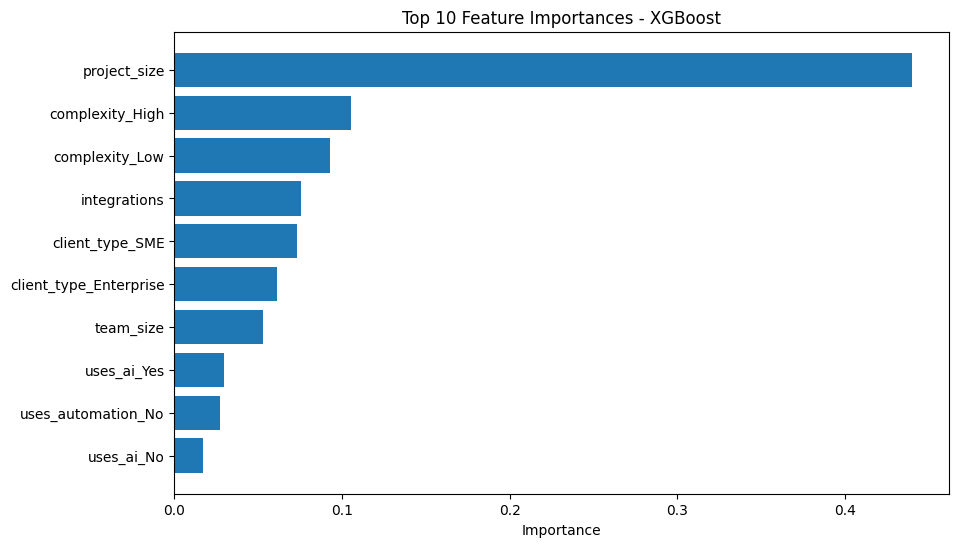

In [34]:
top_xgb = xgb_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_xgb['Feature'][::-1], top_xgb['Importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()

In [35]:
new_project = pd.DataFrame([{
    'project_size': 40,
    'team_size': 4,
    'complexity': 'High',
    'client_type': 'Enterprise',
    'integrations': 3,
    'uses_ai': 'Yes',
    'uses_automation': 'Yes'
}])

predicted_hours = xgb_pipeline.predict(new_project)
print("Predicted project hours:", round(predicted_hours[0], 2))

Predicted project hours: 314.47
